<a href="https://colab.research.google.com/github/dibugeolineal-lab/train_yolo11_dump_truck_colab/blob/main/train_yolo11_dump_truck_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrenamiento de YOLO11 con el dataset `dump-truck-co7as`




## 1) Verificar GPU en Colab



In [1]:
!nvidia-smi


Mon Mar  9 03:47:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2) Instalar dependencias

Se usan versiones fijadas para mejorar la reproducibilidad.


In [11]:
%pip install -q ultralytics==8.4.21 roboflow==1.2.16 PyYAML matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.6 MB/s eta 0:00:00


## 3) Configuración general


In [4]:
import os
import shutil
import random
from pathlib import Path
import yaml
import pandas as pd

HOME = Path.cwd()
print("HOME:", HOME)


HOME: /content


## 4) Cargar la API key



In [5]:
try:
    from google.colab import userdata
    ROBOFLOW_API_KEY = userdata.get("ROBOFLOW_API_KEY")
except Exception:
    ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")

if not ROBOFLOW_API_KEY:
    raise ValueError("No se encontró ROBOFLOW_API_KEY. Cárgala en Colab Secrets o como variable de entorno.")

print("API key cargada correctamente.")


API key cargada correctamente.


## 5) Descargar el dataset desde Roboflow


In [8]:
from roboflow import Roboflow

WORKSPACE = "angelas-workspace-btupm"
PROJECT = "dump-truck-co7as"
VERSION = 1
FORMAT = "yolov11"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)
dataset = version.download(FORMAT)

print("Dataset descargado en:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dump-truck-1 in yolov11:: 100%|██████████| 549/549 [00:00<00:00, 8753.58it/s]

Dataset descargado en: /content/dump-truck-1


In [7]:
%pip install -q roboflow==1.2.16

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 138.8 MB/s eta 0:00:00


## 6) Revisar `data.yaml`


In [9]:
data_yaml = Path(dataset.location) / "data.yaml"
print(data_yaml)

with open(data_yaml, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

data_config

/content/dump-truck-1/data.yaml


{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 1,
 'names': ['dump-truck'],
 'roboflow': {'workspace': 'angelas-workspace-btupm',
  'project': 'dump-truck-co7as',
  'version': 1,
  'license': 'CC BY 4.0',
  'url': 'https://app.roboflow.com/angelas-workspace-btupm/dump-truck-co7as/1'}}

## 7) Entrenar el modelo



In [12]:
from ultralytics import YOLO

MODEL_NAME = "yolo11n.pt"
EPOCHS = 50
IMGSZ = 640
BATCH = 8
RUN_NAME = "dump_truck_yolo11"
PROJECT_DIR = HOME / "runs"

model = YOLO(MODEL_NAME)

results = model.train(
    data=str(data_yaml),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=0,
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dump-truck-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=

## 8) Validar el modelo entrenado


In [18]:
run_dir = PROJECT_DIR / RUN_NAME
best_model = run_dir / "weights" / "best.pt"
print("Modelo best:", best_model)

best = YOLO(str(best_model))
val_metrics = best.val(data=str(data_yaml), split="val")
display(val_metrics)

Modelo best: /content/runs/dump_truck_yolo11/weights/best.pt
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1496.6±352.5 MB/s, size: 44.6 KB)
val: Scanning /content/dump-truck-1/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.7it/s 0.3s
                   all         10         10      0.991          1      0.995      0.826
Speed: 2.1ms preprocess, 5.8ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c52280f2c60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## 9) Generar predicciones sobre imágenes de prueba


In [14]:
test_images_dir = Path(dataset.location) / "test" / "images"
pred_dir = run_dir / "predictions"
pred_dir.mkdir(parents=True, exist_ok=True)

image_paths = sorted([p for p in test_images_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
sample_images = image_paths[: min(5, len(image_paths))]
print("Imágenes de prueba seleccionadas:", len(sample_images))

pred_results = best.predict(
    source=[str(p) for p in sample_images],
    conf=0.25,
    save=True,
    project=str(run_dir),
    name="predictions",
    exist_ok=True,
)


Imágenes de prueba seleccionadas: 5

0: 640x640 1 dump-truck, 9.4ms
1: 640x640 3 dump-trucks, 9.4ms
2: 640x640 1 dump-truck, 9.4ms
3: 640x640 1 dump-truck, 9.4ms
4: 640x640 1 dump-truck, 9.4ms
Speed: 1.7ms preprocess, 9.4ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/dump_truck_yolo11/predictions


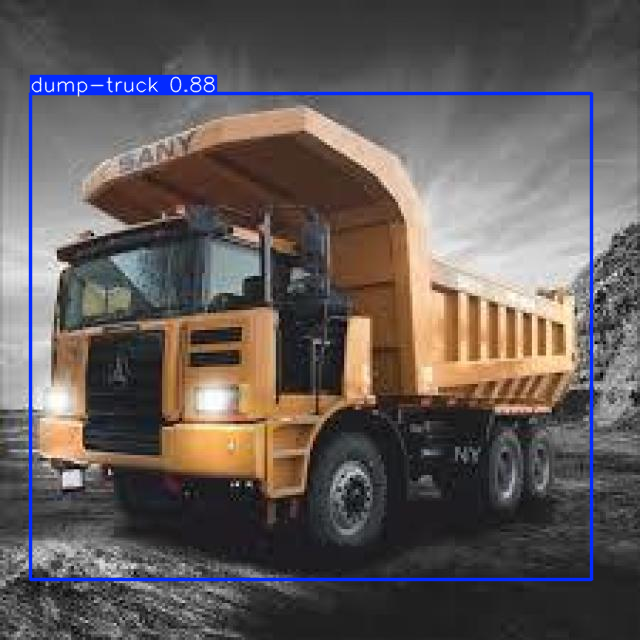

In [22]:
# Mostrar predicciones
pred_results[0].show()

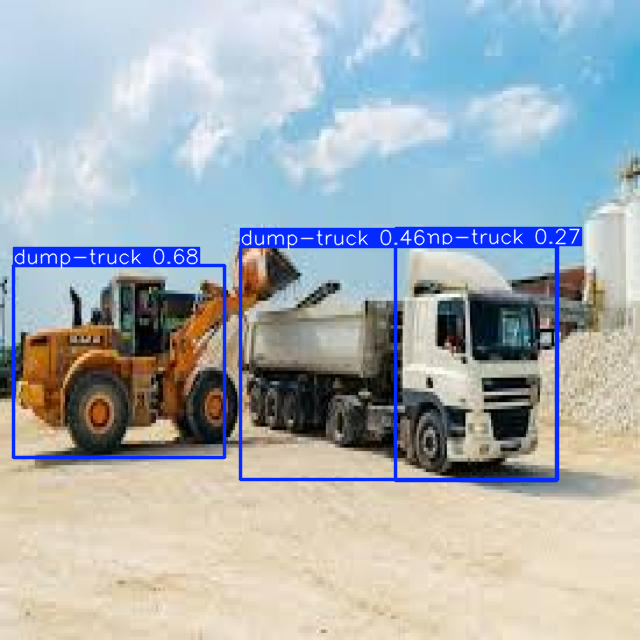

In [24]:
pred_results[1].show()

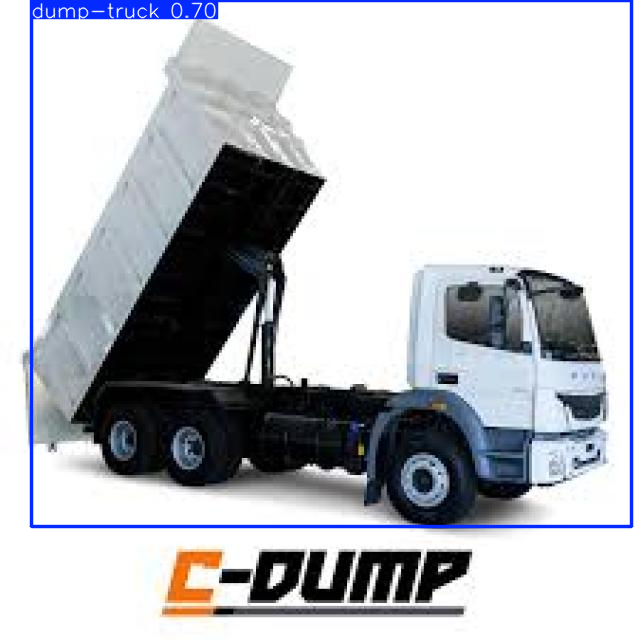

In [28]:
pred_results[3].show()

## 10) Revisar métricas principales


In [15]:
results_csv = run_dir / "results.csv"
if results_csv.exists():
    df = pd.read_csv(results_csv)
    display(df.tail())
else:
    print("No se encontró results.csv")


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,300.425,0.51942,0.44141,1.22950,0.88592,1.00000,0.98591,0.78449,0.61336,0.53848,1.28227,0.000218,0.000218,0.000218
46,47,307.011,0.48274,0.42022,1.18300,0.90750,0.98248,0.98591,0.75437,0.67769,0.51723,1.36783,0.000178,0.000178,0.000178
47,48,312.815,0.47149,0.42834,1.16718,0.99322,1.00000,0.99500,0.75996,0.71775,0.47071,1.42885,0.000139,0.000139,0.000139
48,49,318.123,0.48331,0.42694,1.17786,0.99497,1.00000,0.99500,0.77258,0.73676,0.42569,1.47829,0.000099,0.000099,0.000099
49,50,324.408,0.48334,0.42770,1.16497,0.99091,1.00000,0.99500,0.80559,0.63022,0.46394,1.34610,0.000060,0.000060,0.000060


## 11) Copiar los artefactos importantes a una carpeta `results/`




In [16]:
export_dir = HOME / "results"
export_dir.mkdir(parents=True, exist_ok=True)
(export_dir / "predictions").mkdir(parents=True, exist_ok=True)
(export_dir / "weights").mkdir(parents=True, exist_ok=True)

files_to_copy = [
    "args.yaml",
    "results.csv",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "PR_curve.png",
]

for fname in files_to_copy:
    src = run_dir / fname
    if src.exists():
        shutil.copy2(src, export_dir / fname)

for fname in ["best.pt", "last.pt"]:
    src = run_dir / "weights" / fname
    if src.exists():
        shutil.copy2(src, export_dir / "weights" / fname)

predictions_dir = run_dir / "predictions"
if predictions_dir.exists():
    for p in predictions_dir.glob("**/*"):
        if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            shutil.copy2(p, export_dir / "predictions" / p.name)

print("Artefactos exportados a:", export_dir)
list(export_dir.rglob("*"))[:20]


Artefactos exportados a: /content/results


[PosixPath('/content/results/confusion_matrix_normalized.png'),
 PosixPath('/content/results/confusion_matrix.png'),
 PosixPath('/content/results/results.csv'),
 PosixPath('/content/results/predictions'),
 PosixPath('/content/results/args.yaml'),
 PosixPath('/content/results/weights'),
 PosixPath('/content/results/predictions/image3.jpg'),
 PosixPath('/content/results/predictions/image2.jpg'),
 PosixPath('/content/results/predictions/image4.jpg'),
 PosixPath('/content/results/predictions/image1.jpg'),
 PosixPath('/content/results/predictions/image0.jpg'),
 PosixPath('/content/results/weights/last.pt'),
 PosixPath('/content/results/weights/best.pt')]

## 12) Comprimir resultados para descargar o subir al repo


In [17]:
zip_path = shutil.make_archive(str(export_dir), 'zip', root_dir=str(export_dir))
print("ZIP generado:", zip_path)


ZIP generado: /content/results.zip


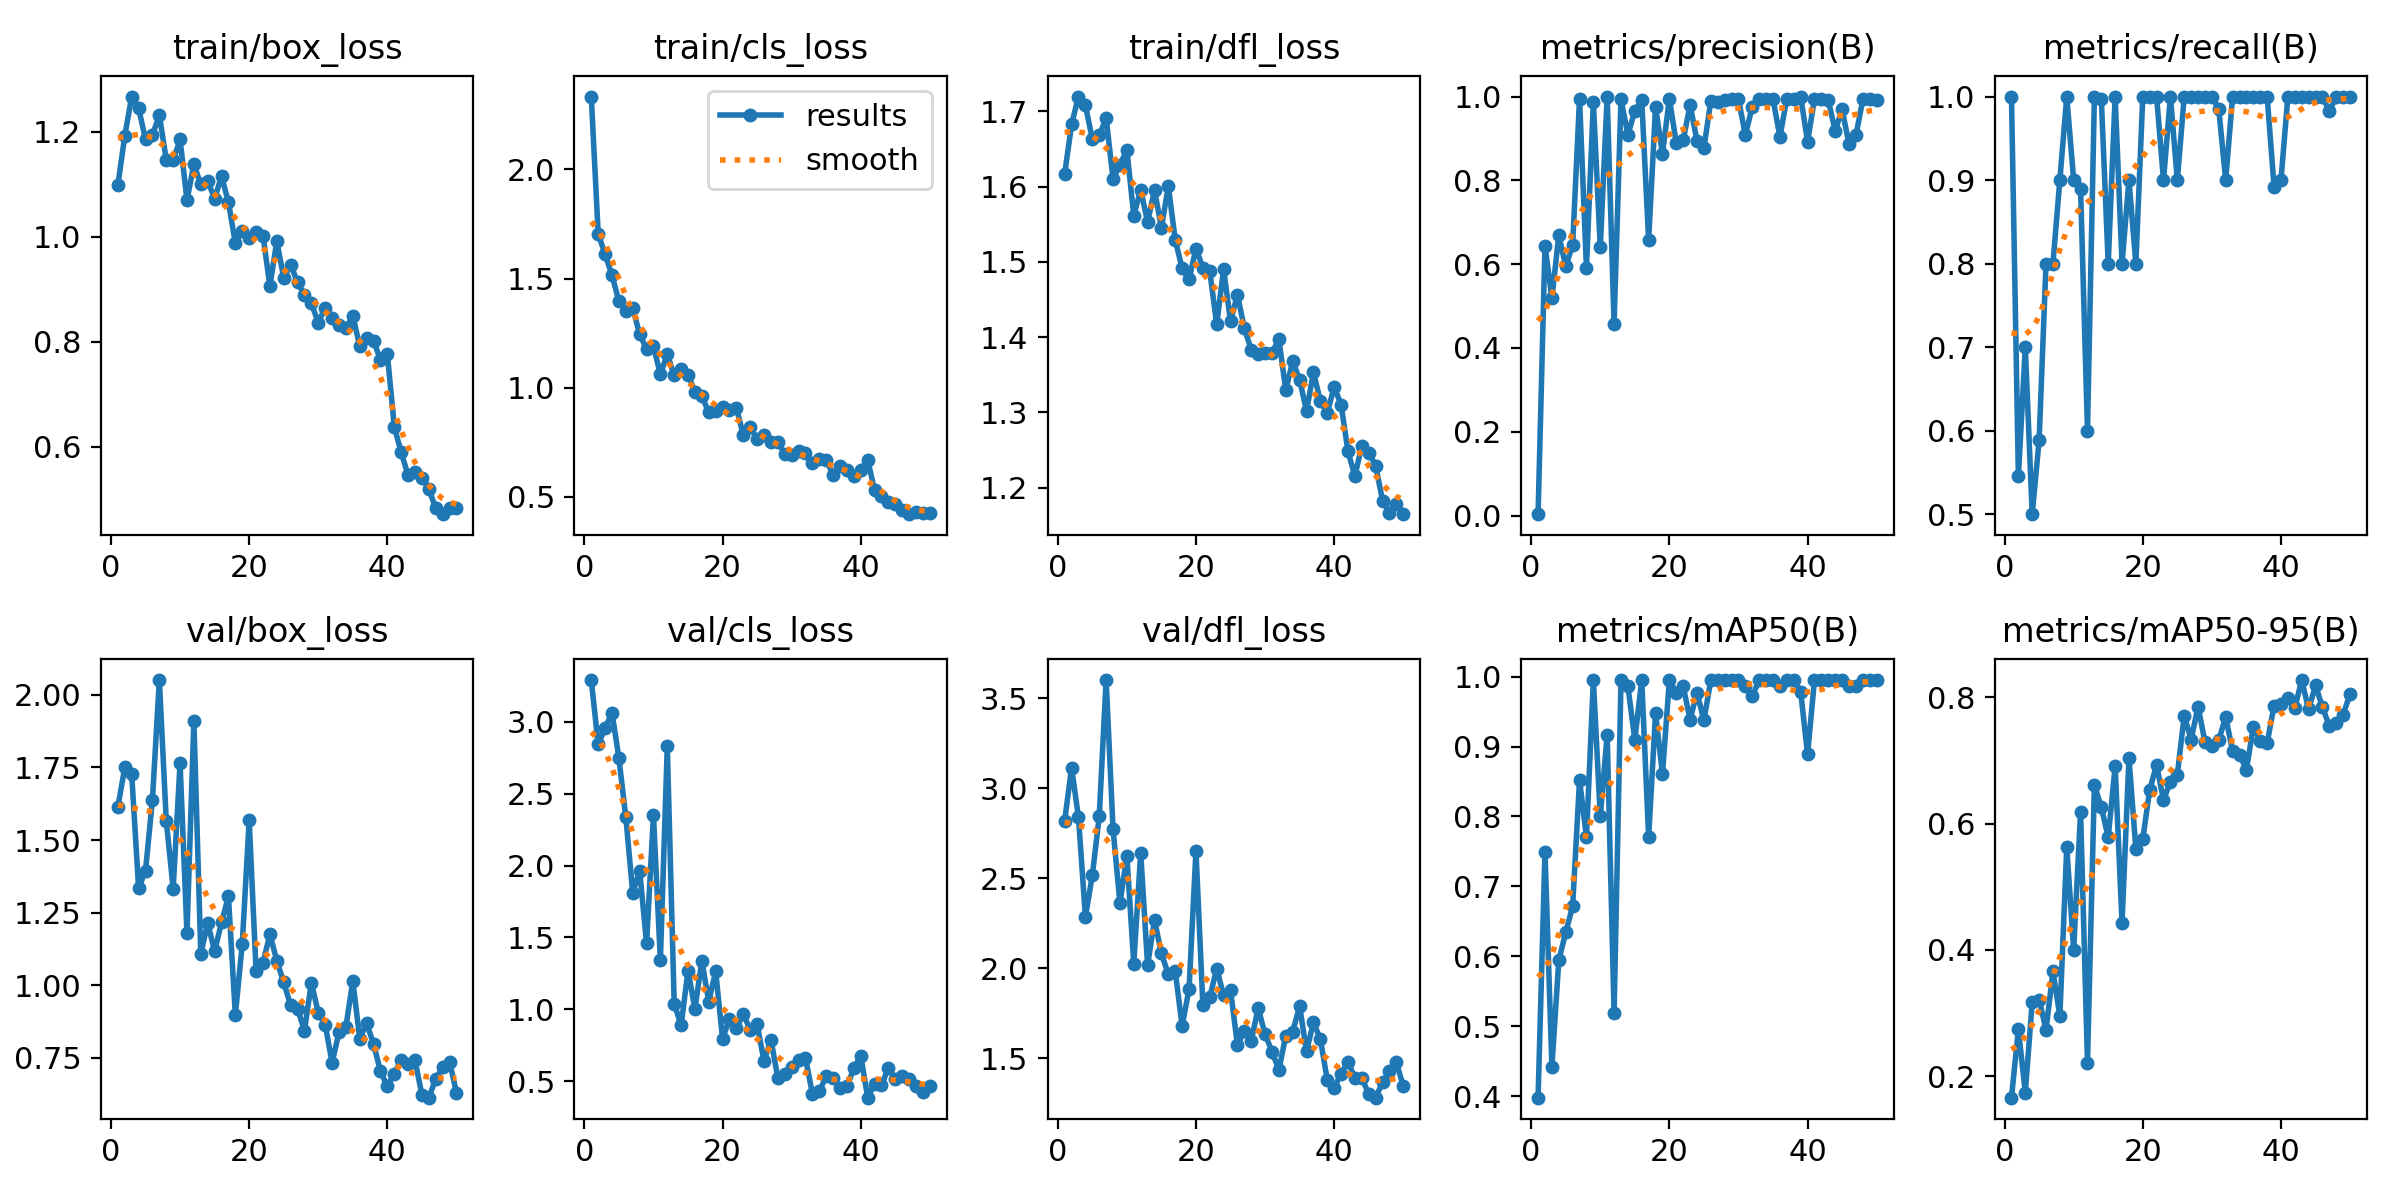

In [20]:
from IPython.display import Image, display

display(Image(filename="runs/dump_truck_yolo11/results.png"))

In [26]:
from ultralytics import YOLO

model = YOLO("runs/dump_truck_yolo11/weights/best.pt")
metrics = model.val(data=str(data_yaml), split="val", plots=True)
print(metrics.save_dir)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1621.7±606.7 MB/s, size: 44.9 KB)
val: Scanning /content/dump-truck-1/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.2it/s 0.3s
                   all         10         10      0.991          1      0.995      0.826
Speed: 1.3ms preprocess, 5.7ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val3
/content/runs/detect/val3


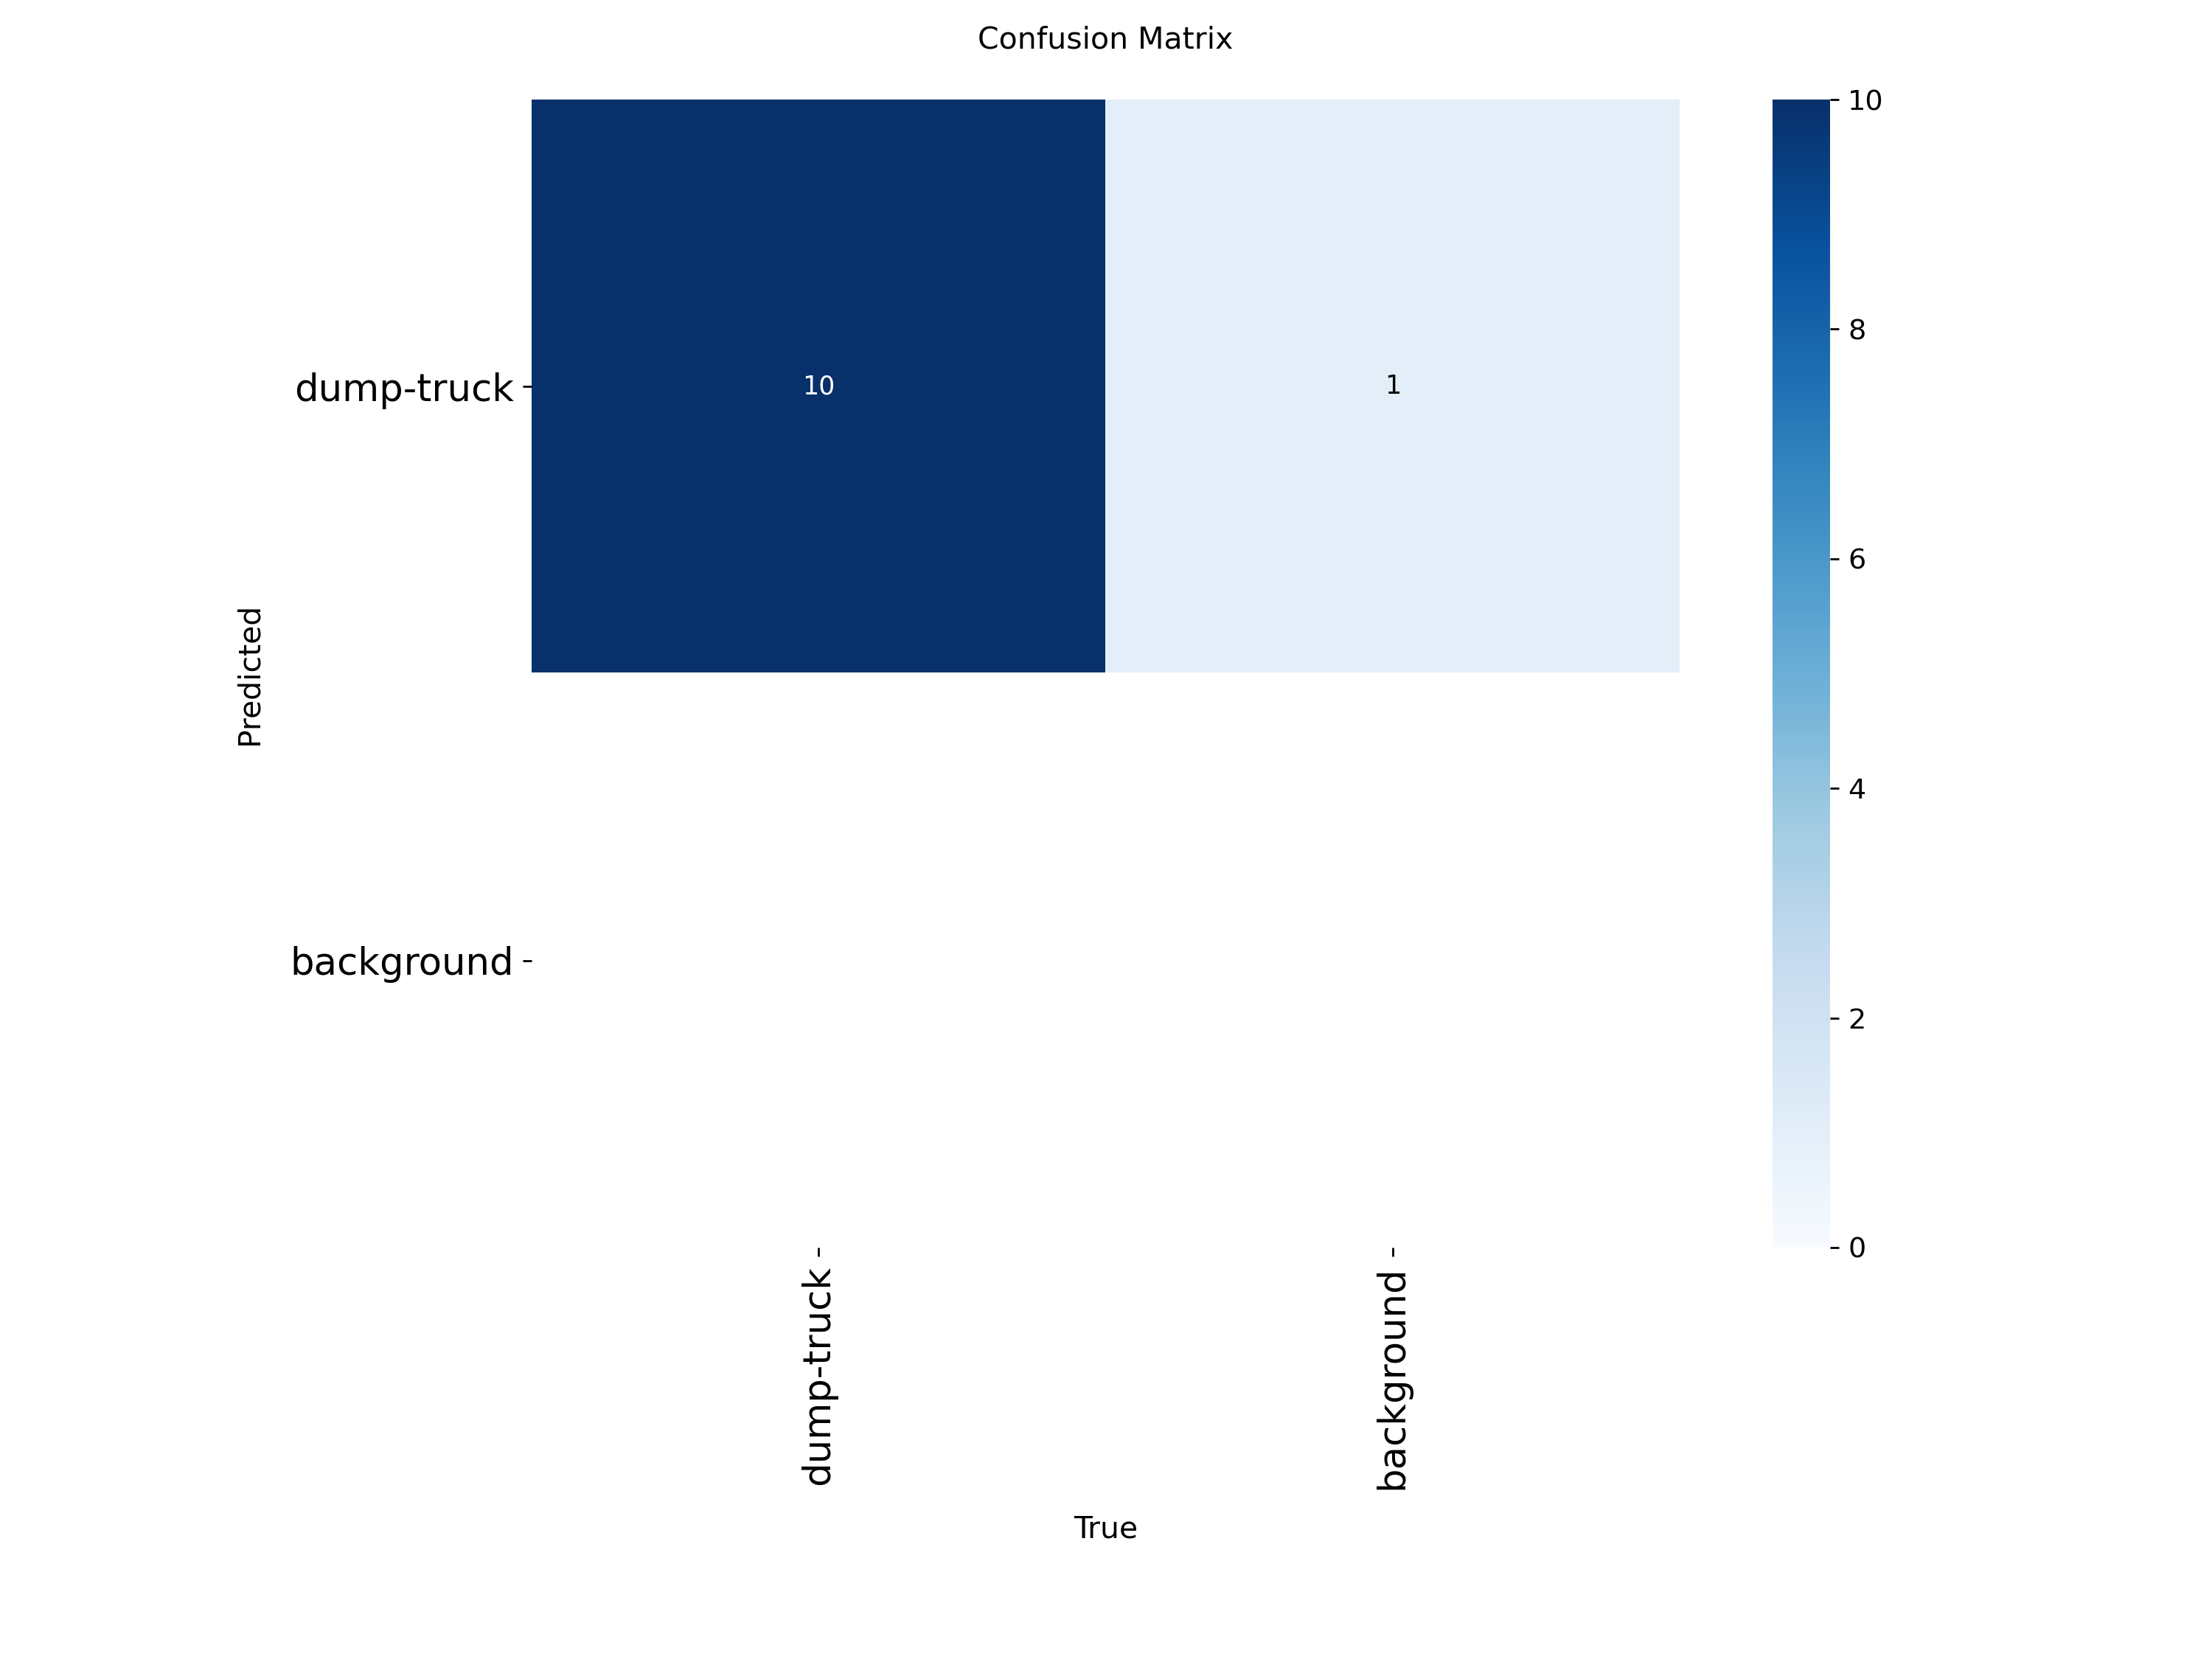

In [27]:


from IPython.display import Image, display

display(Image(filename="/content/runs/detect/val3/confusion_matrix.png"))